# TM10007 Assignment template

In [4]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

^C


## Importing packages 


In [1]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn import model_selection
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import zscore, shapiro





## Data loading and cleaning

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [2]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data splitting

In [3]:
# Split the dataset in features and labels
X = data_binary.drop(columns=["label"])
y = data_binary["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")

The number of samples in the train set: 148
The number of samples in the test set: 38


## Pre-Processing


In [4]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_binary = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_binary.columns[data_binary.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_binary = data_binary.loc[:, ~data_binary.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for constant features
constant_features = data_binary.columns[data_binary.nunique() == 1]
print(f"Number of constant features: {len(constant_features)}")
if len(constant_features) > 0:
    print(f"Constant features names: {list(constant_features)}")
    data_binary.drop(columns=constant_features, inplace=True)

# Checking for missing data
# Print the number of missing values
print(f"Amount of missing data: {data_binary.isna().sum().sum()}")  
# Print the number of zeros per feature
zero_counts = (data_binary.drop(columns=['label']) == 0).sum()
features_with_zeros = zero_counts[zero_counts > 0]
print(f"\nPercentage of zeros per feature: \n{features_with_zeros/len(data_binary.index)*100}")

# Remove columns with =/> 10% zeros
features_to_remove_zeros = features_with_zeros[features_with_zeros > 0.1*len(data_binary.index)].index
data_binary.drop(columns=features_to_remove_zeros, inplace=True)
print(f"Removed features with more than 10% zeros: {list(features_to_remove_zeros)}")

# Columns with < 10% zeros
features_remaining_with_features = features_with_zeros[features_with_zeros <= 0.1*len(data_binary.index)].index
print(f"Features with less than 10% zeros: {list(features_remaining_with_features)}")



No duplicate sample found.
No duplicate features found.
Number of constant features: 17
Constant features names: ['PREDICT_original_tf_LBP_min_R3_P12', 'PREDICT_original_tf_LBP_max_R3_P12', 'PREDICT_original_tf_LBP_peak_R3_P12', 'PREDICT_original_tf_LBP_peak_position_R3_P12', 'PREDICT_original_tf_LBP_range_R3_P12', 'PREDICT_original_tf_LBP_max_R8_P24', 'PREDICT_original_tf_LBP_peak_R8_P24', 'PREDICT_original_tf_LBP_peak_position_R8_P24', 'PREDICT_original_tf_LBP_max_R15_P36', 'PREDICT_original_tf_LBP_peak_R15_P36', 'PREDICT_original_tf_LBP_peak_position_R15_P36', 'PREDICT_original_phasef_phasecong_min_WL3_N5', 'PREDICT_original_phasef_phasecong_peak_WL3_N5', 'PREDICT_original_phasef_phasecong_peak_position_WL3_N5', 'PREDICT_original_phasef_phasesym_min_WL3_N5', 'PREDICT_original_phasef_phasesym_peak_WL3_N5', 'PREDICT_original_phasef_phasesym_peak_position_WL3_N5']
Amount of missing data: 0

Percentage of zeros per feature: 
PREDICT_original_tf_LBP_min_R8_P24                            

## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [5]:
# Checking the distribution of the features
#for column in X.columns:
    #sns.histplot(X[column], kde=True, bins=30)
    #plt.title(f"Distribution of {column}")
    #plt.show()

# Check for outliers and normality
z_scores = np.abs(zscore(X_train))
outlier_counts = (z_scores > 3).sum(axis=0)

shapiro_pvalues = {}
for col in X_train.columns:
    data_col = X_train[col].sample(n=5000, random_state=42) if len(X_train) > 5000 else X_train[col]
    try:
        _, p_value = shapiro(data_col)
    except:
        p_value = np.nan
    shapiro_pvalues[col] = p_value

# Outlier counts and Shapiro-Wilk p-values
outlier_df = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Shapiro-Wilk p-value': pd.Series(shapiro_pvalues)
}).sort_values('Outlier Count', ascending=False)

# Summary
outlier_threshold = 5
num_features_with_outliers = (outlier_df["Outlier Count"] > outlier_threshold).sum()
non_normal_features = (outlier_df["Shapiro-Wilk p-value"] < 0.05).sum()
total_features = outlier_df.shape[0]

print(f"Number of features with more than {outlier_threshold} outliers: {num_features_with_outliers}")
print(f"Number of non-normal distributed features: {non_normal_features}")  
print(f"Number of normal distributed features: {total_features - non_normal_features}")

Number of features with more than 5 outliers: 4
Number of non-normal distributed features: 423
Number of normal distributed features: 70


C:\Users\tarav\AppData\Local\Temp\ipykernel_17676\113935050.py:8: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(zscore(X_train))
c:\Users\tarav\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


Try different scaling methods and compare them to see which works best for the dataset.

In [9]:
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Apply each scaler to the data
scaled_data = {}
for name, scaler in scalers.items():
    scaled_data[name]=scaler.fit_transform(X)

# Compare model performance with different scalers
results = {}

for name, X in scaled_data.items():
    X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    clf = RandomForestClassifier(n_estimators= 100, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy
    print(f"Accuracy with {name}: {accuracy:.4f}")

Accuracy with StandardScaler: 0.6053
Accuracy with MinMaxScaler: 0.6053
Accuracy with RobustScaler: 0.6053


Check if scaling is actually changing the data.

In [7]:
X_scaled = StandardScaler().fit_transform(X)

df_compare = pd.DataFrame({'Original': X.iloc[:, 0], 'Scaled': X_scaled[:, 0]})
print(df_compare.describe())

         Original        Scaled
count  186.000000  1.860000e+02
mean     0.808754 -1.260640e-15
std      0.070161  1.002699e+00
min      0.549046 -3.711599e+00
25%      0.773570 -5.028324e-01
50%      0.824074  2.189462e-01
75%      0.857698  6.994810e-01
max      0.926346  1.680567e+00


In [14]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

# Ensure only numeric columns are processed
if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=X.columns if isinstance(X, pd.DataFrame) else [f"Feature_{i}" for i in range(X_train.shape[1])])
numeric_columns = X_train.select_dtypes(include=[np.number]).columns

for column in numeric_columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > 0.05 * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(numeric_columns)) * 100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(numeric_columns)} = {perc_columns_many_outliers:.2f}%")

Number of columns with many outliers: 166/493 = 33.67%


### Scaling the data

c:\Users\tarav\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


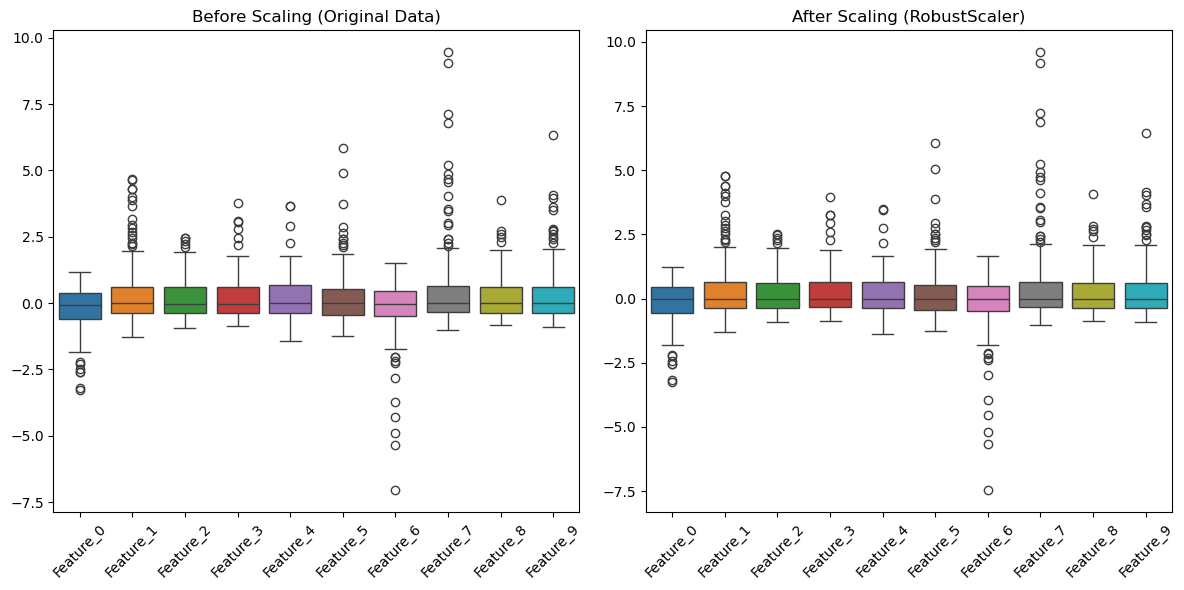

In [21]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled) 

features_to_plot = X_train.columns[:10] 
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot original (unscaled) data
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[features_to_plot])
plt.title("Before Scaling (Original Data)")
plt.xticks(rotation=45)

# Plot scaled data
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[features_to_plot])
plt.title("After Scaling (RobustScaler)")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()
